Dataset loaded:
  EntryID               OrganismName        Kingdom  SequenceLength  SPStart  \
0  Q16552               Homo sapiens        Metazoa             155      1.0   
1  Q9M373       Arabidopsis thaliana  Viridiplantae              74      1.0   
2  P62520  Chilobrachys guangxiensis        Metazoa              63      1.0   
3  Q8I7X1           Porcellio scaber        Metazoa             145      1.0   
4  P14625               Homo sapiens        Metazoa             803      1.0   

   SPEnd     Label HelixDomain  \
0   23.0  Positive         NaN   
1   26.0  Positive         NaN   
2   27.0  Positive         NaN   
3   21.0  Positive         NaN   
4   21.0  Positive         NaN   

                                            Sequence  Set  
0  MTPGKTSLVSLLLLLSLEAIVKAGITIPRNPGCPNSEDKNFPRTVM...  4.0  
1  MASRNSVAVIALFAFVFAVISPFAGAQSLAPAPSPTSDGTSIDQGI...  1.0  
2  MKNTSILFILGLALLLVLAFEAQVGESDGECGGFWWKCGRGKPPCC...  2.0  
3  MKGLLFIVSLLCLTLHQRVWAYQVIGMKSDVICADIRFTVHCICNE...  4.0 

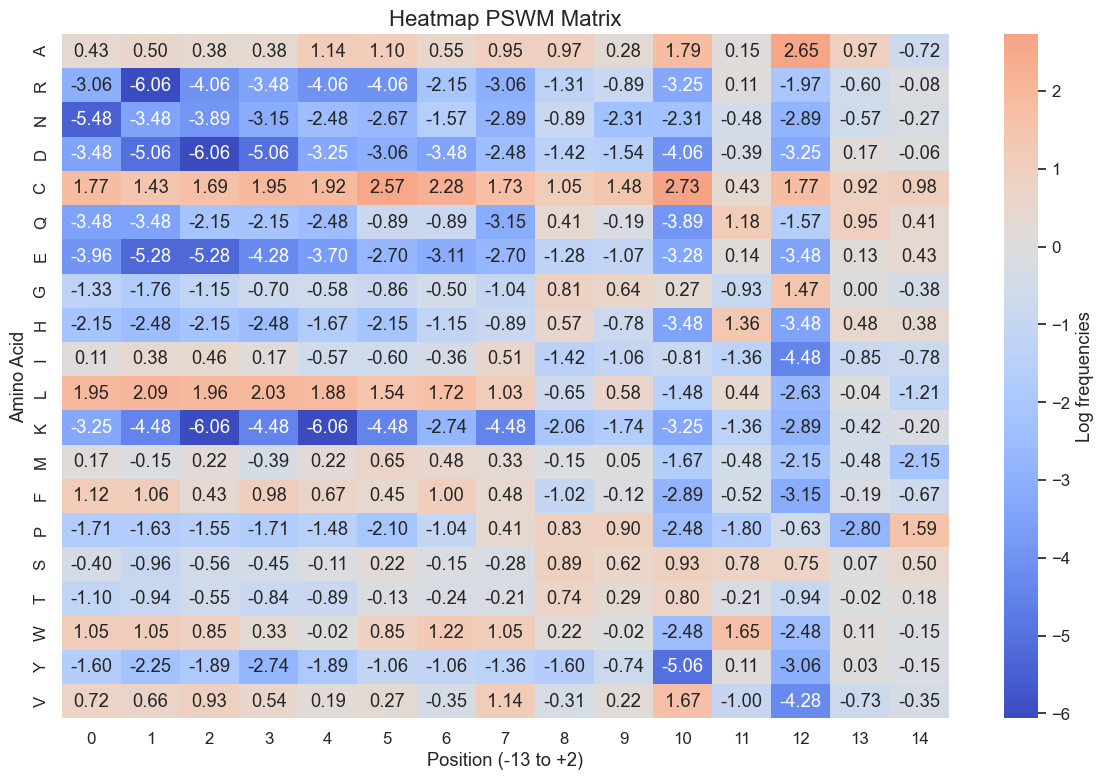

Scoring completed!
  EntryID     Label  vonHeijne_Score
0  Q16552  Positive        11.248437
1  Q9M373  Positive         9.833584
2  P62520  Positive        12.967732
3  Q8I7X1  Positive        14.098521
4  P14625  Positive        15.230660
🔄 'Set' column is missing or invalid. Recreating it...
✅ New 'Set' column created.
Set
0    2006
1    2006
2    2005
3    2005
4    2005
Name: count, dtype: int64

=== FOLD 1 ===
Train: 6015, Validation: 2006, Test: 2006


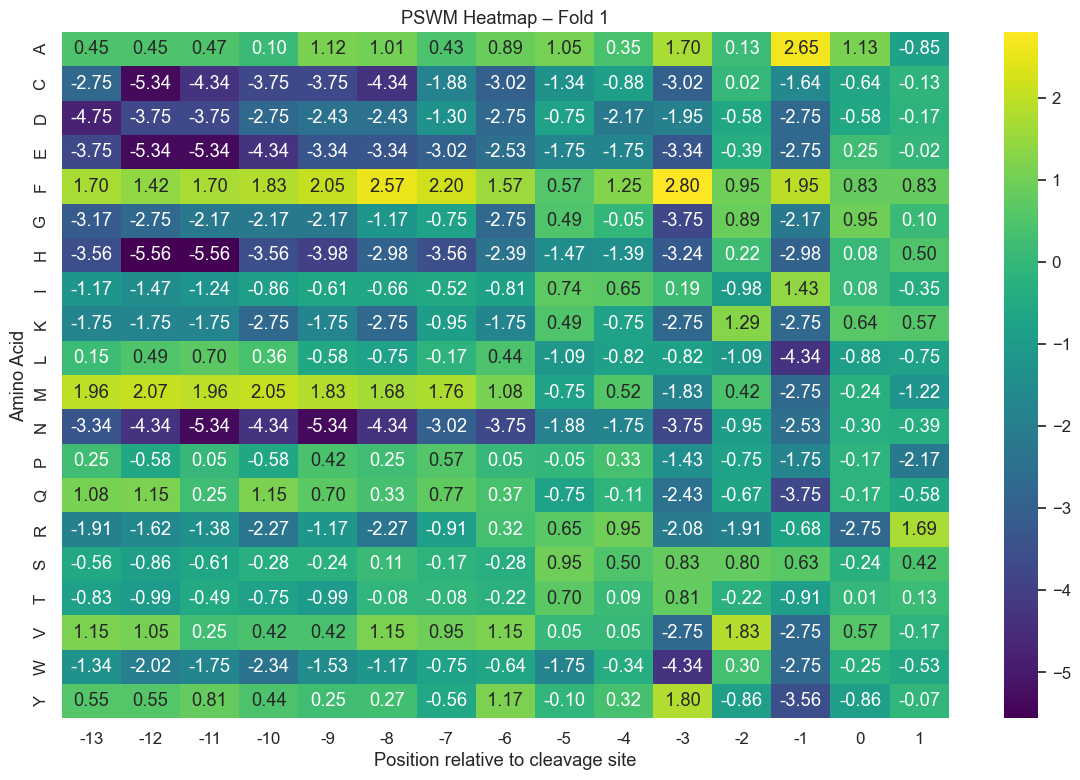

Optimal threshold: 8.7808


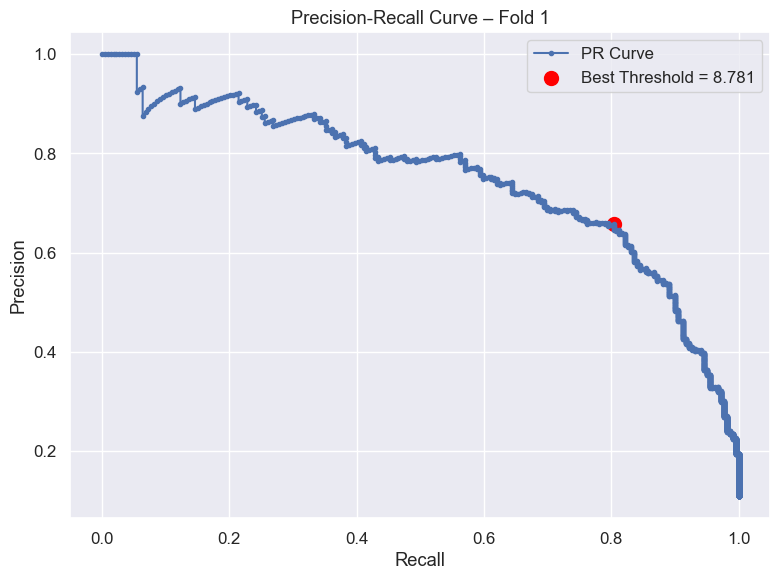

MCC: 0.674672
Precision: 0.669355
Accuracy: 0.932702
Sensitivity: 0.757991
Confusion Matrix:
[[1705   82]
 [  53  166]]

=== FOLD 2 ===
Train: 6016, Validation: 2005, Test: 2006


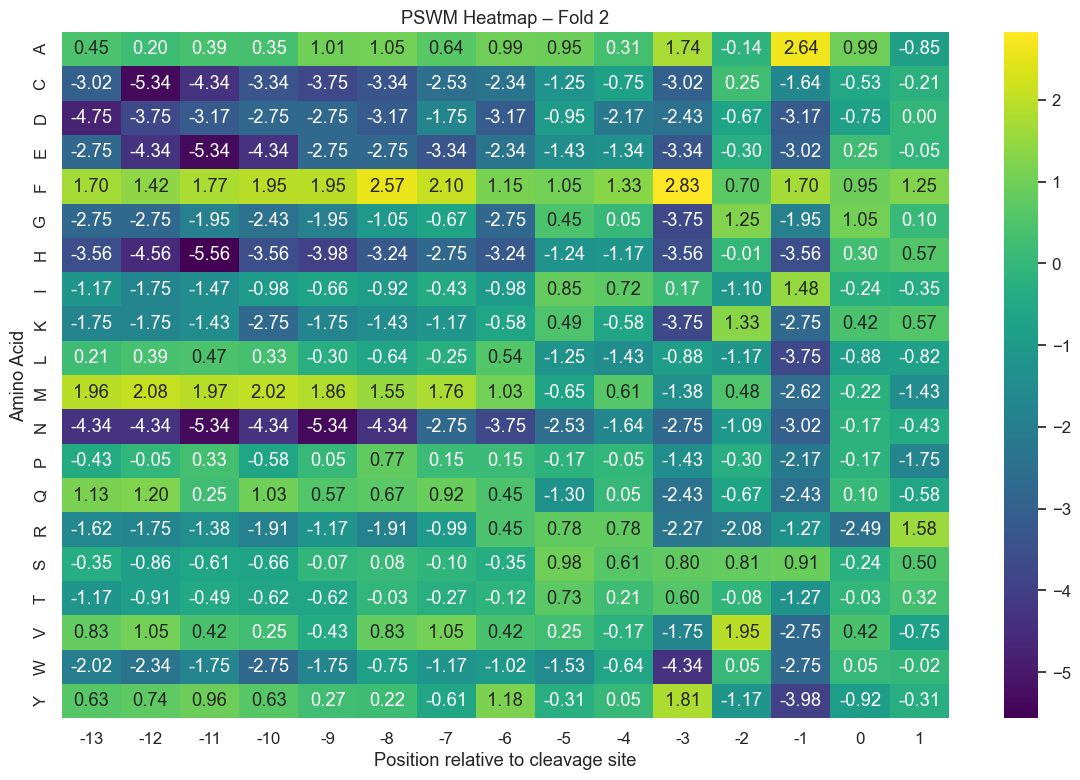

Optimal threshold: 9.1094


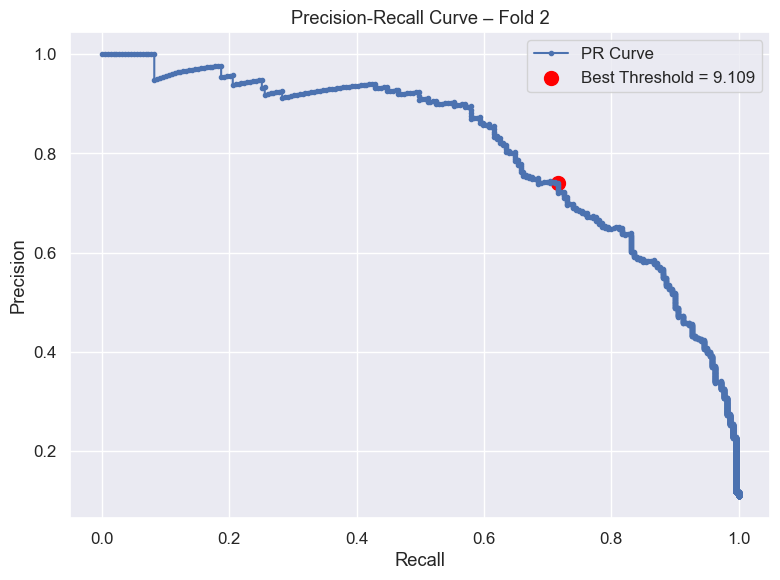

MCC: 0.675221
Precision: 0.677686
Accuracy: 0.933699
Sensitivity: 0.748858
Confusion Matrix:
[[1709   78]
 [  55  164]]

=== FOLD 3 ===
Train: 6017, Validation: 2005, Test: 2005


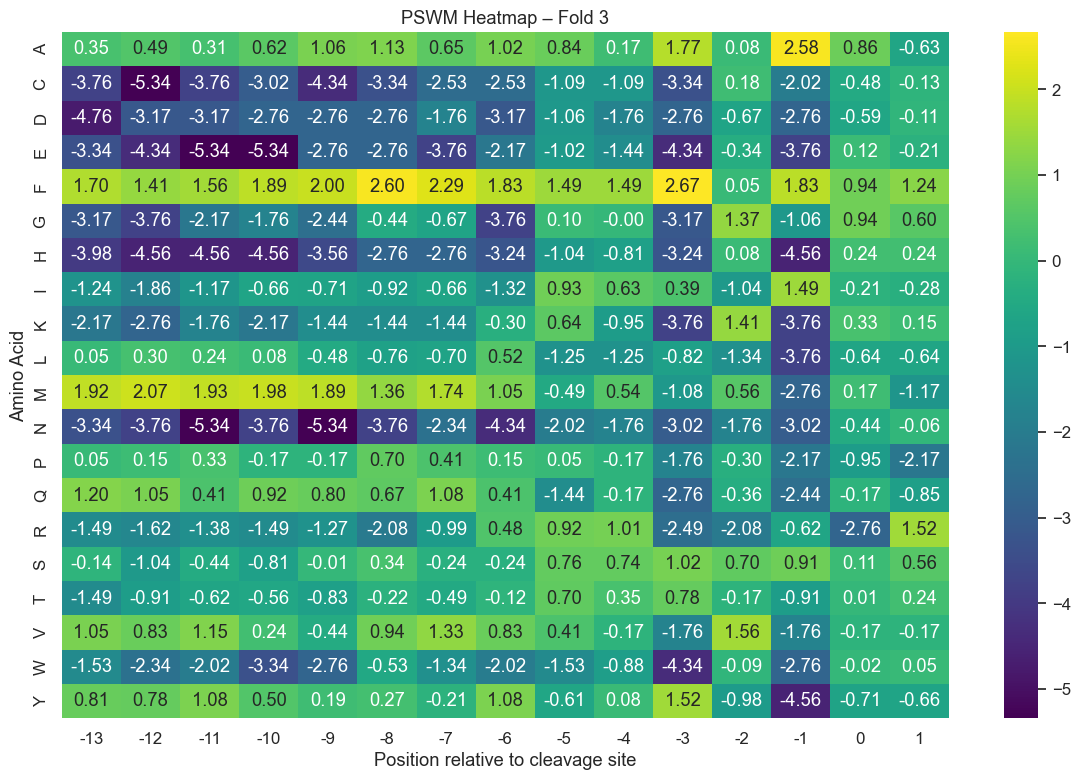

Optimal threshold: 9.9277


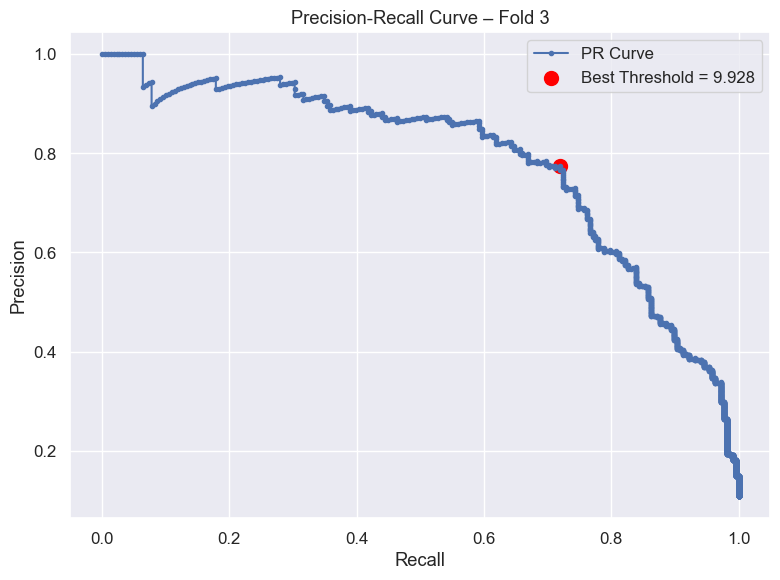

MCC: 0.672841
Precision: 0.757895
Accuracy: 0.939651
Sensitivity: 0.657534
Confusion Matrix:
[[1740   46]
 [  75  144]]

=== FOLD 4 ===
Train: 6017, Validation: 2005, Test: 2005


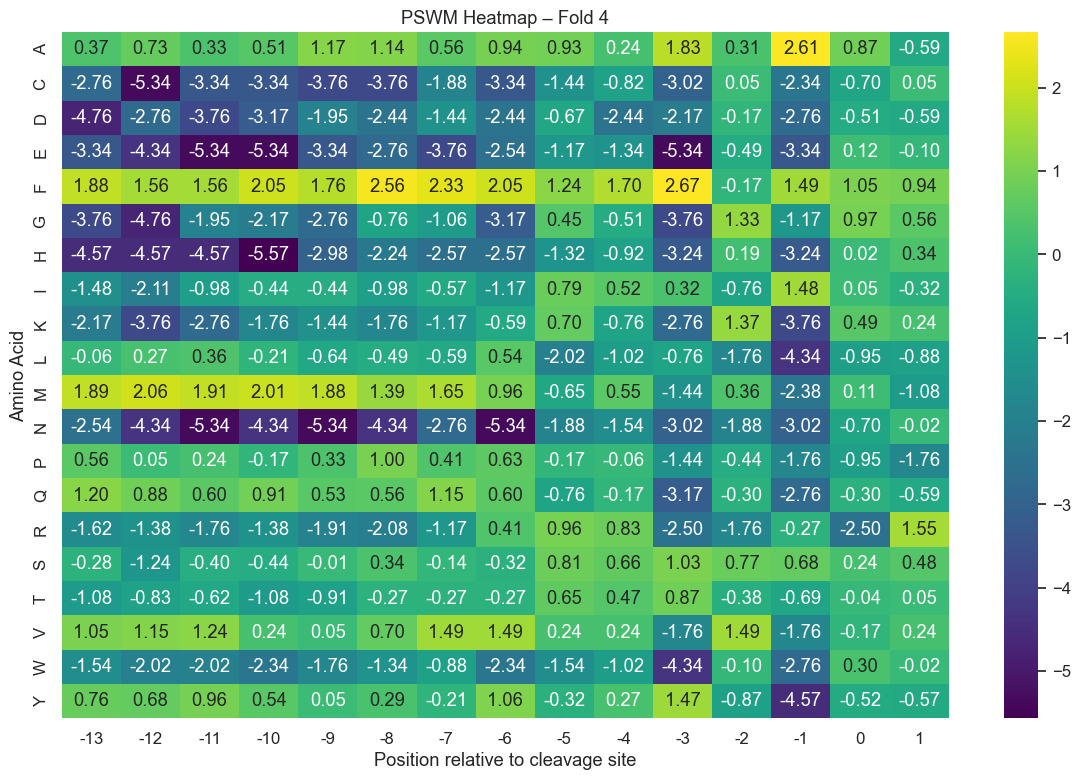

Optimal threshold: 8.5230


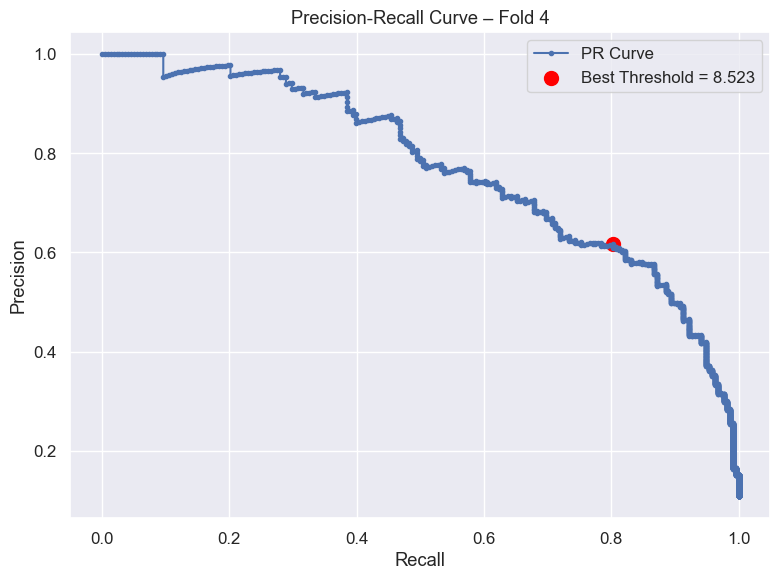

MCC: 0.649079
Precision: 0.623134
Accuracy: 0.924190
Sensitivity: 0.766055
Confusion Matrix:
[[1686  101]
 [  51  167]]

=== FOLD 5 ===
Train: 6016, Validation: 2006, Test: 2005


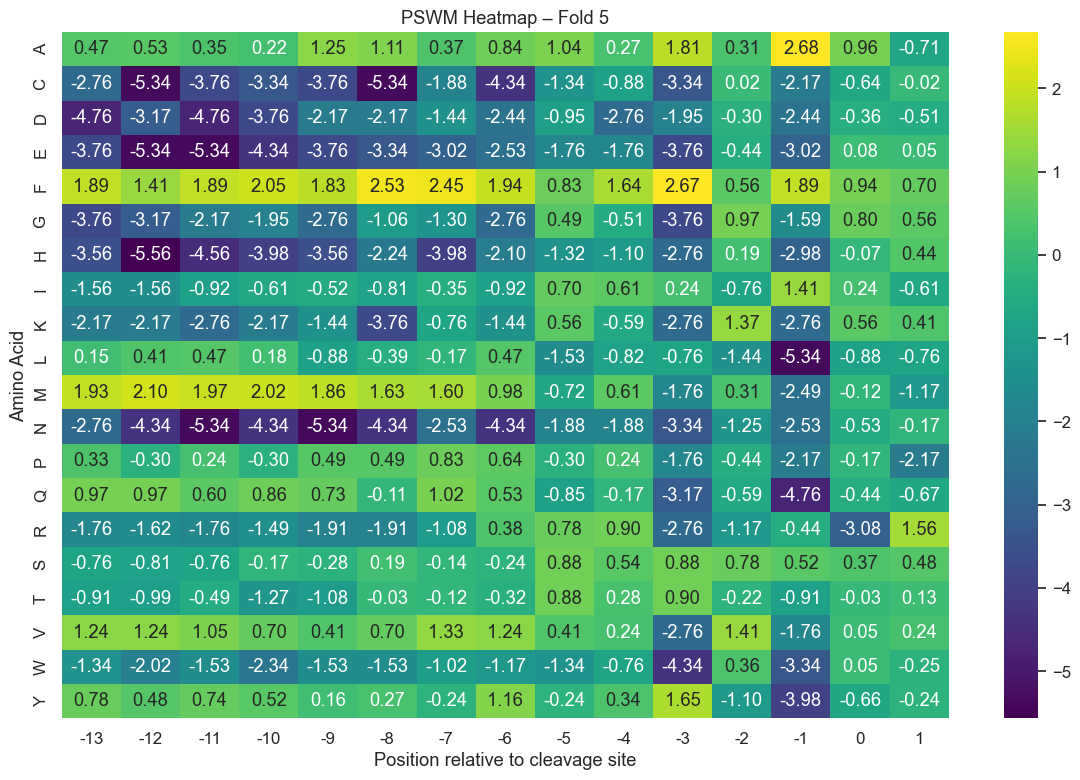

Optimal threshold: 8.4965


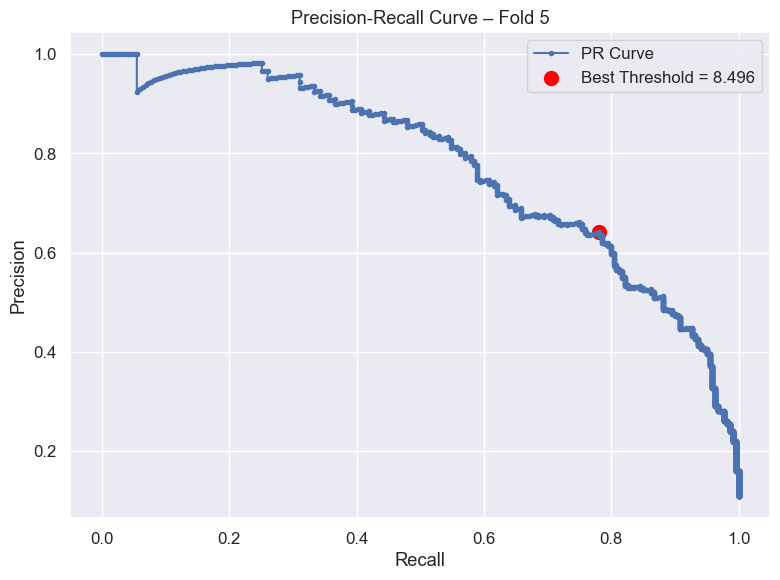

MCC: 0.660417
Precision: 0.620072
Accuracy: 0.924688
Sensitivity: 0.793578
Confusion Matrix:
[[1681  106]
 [  45  173]]

✅ AVERAGE METRICS (5-FOLD CROSS-VALIDATION)
MCC: 0.666446 ± 0.011440
Precision: 0.669628 ± 0.055842
Accuracy: 0.930986 ± 0.006543
Sensitivity: 0.744803 ± 0.051568

Average Confusion Matrix:
[[1704   82]
 [  55  162]]


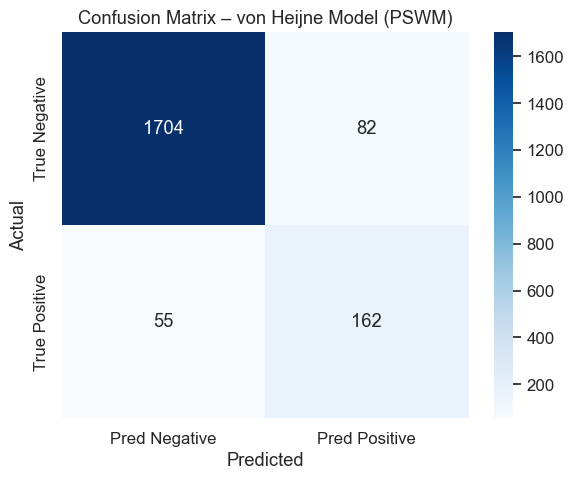

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("data.tsv", sep="\t")

print("Dataset loaded:")
print(df.head())

# SwissProt amino acid frequencies
swissprot_freq = {
    'A': 0.08, 'R': 0.06, 'N': 0.04, 'D': 0.06, 'C': 0.01,
    'Q': 0.04, 'E': 0.07, 'G': 0.07, 'H': 0.02, 'I': 0.06,
    'L': 0.10, 'K': 0.06, 'M': 0.02, 'F': 0.04, 'P': 0.05,
    'S': 0.07, 'T': 0.05, 'W': 0.01, 'Y': 0.03, 'V': 0.07
}

def extract_cleavage_context(sequence, sp_end, window_size=15):
    cleavage_pos = int(sp_end)
    start_pos = cleavage_pos - 13
    end_pos = cleavage_pos + 2

    if start_pos < 0 or end_pos > len(sequence):
        return None

    context = sequence[start_pos:end_pos]
    if len(context) != window_size:
        return None
    return context

def build_pswm_heatmap(sequences, window_size=15, pseudocount=1):
    aa_list = list(swissprot_freq.keys())
    aa_to_idx = {aa: i for i, aa in enumerate(aa_list)}

    count_matrix = np.ones((len(aa_list), window_size))

    for seq in sequences:
        if len(seq) != window_size:
            continue
        for j, aa in enumerate(seq):
            if aa in aa_to_idx:
                count_matrix[aa_to_idx[aa], j] += 1

    N = len(sequences)
    pspm = count_matrix / (N + 20)

    pswm = np.zeros_like(pspm)
    for i, aa in enumerate(aa_list):
        pswm[i, :] = np.log2(pspm[i, :] / swissprot_freq[aa])
    return pswm, aa_list

positive_sequences = df[df['Label'] == 'Positive']

cleavage_contexts = []
for _, row in positive_sequences.iterrows():
    seq = row['Sequence']
    sp_end = row['SPEnd']
    context = extract_cleavage_context(seq, sp_end)
    if context:
        cleavage_contexts.append(context)

pswm, aa_list = build_pswm_heatmap(cleavage_contexts)

plt.figure(figsize=(12, 8))
sns.set(font_scale=1.1)
ax = sns.heatmap(
    pswm,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    xticklabels=[f"{i}" for i in range(15)],
    yticklabels=aa_list,
    cbar_kws={'label': 'Log frequencies'}
)

plt.title('Heatmap PSWM Matrix', fontsize=16)
plt.xlabel('Position (-13 to +2)')
plt.ylabel('Amino Acid')
plt.tight_layout()
plt.show()

aa_list = list(swissprot_freq.keys())
aa_to_idx = {aa: i for i, aa in enumerate(aa_list)}

def score_protein_sequence(seq, pswm, aa_to_idx, window_size=15, n_terminal=90):
    seq = seq[:n_terminal]

    if len(seq) < window_size:
        return -1000.0

    max_score = -np.inf

    for i in range(len(seq) - window_size + 1):
        subseq = seq[i:i + window_size]
        score = 0.0
        valid = True

        for j, aa in enumerate(subseq):
            if aa not in aa_to_idx:
                valid = False
                break
            score += pswm[aa_to_idx[aa], j]

        if valid and score > max_score:
            max_score = score

    return max_score if max_score != -np.inf else -1000.0

df['vonHeijne_Score'] = df['Sequence'].apply(
    lambda x: score_protein_sequence(x, pswm, aa_to_idx)
)

print("Scoring completed!")
print(df[['EntryID', 'Label', 'vonHeijne_Score']].head())

from sklearn.model_selection import StratifiedKFold

if 'Set' not in df.columns or set(df['Set'].unique()) != {0, 1, 2, 3, 4}:
    print("🔄 'Set' column is missing or invalid. Recreating it...")
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    df['Set'] = -1
    for fold, (_, test_idx) in enumerate(skf.split(df, df['Label'])):
        df.loc[test_idx, 'Set'] = fold
    print("✅ New 'Set' column created.")
    print(df['Set'].value_counts().sort_index())

from sklearn.metrics import (
    matthews_corrcoef,
    precision_score,
    recall_score,
    accuracy_score,
    confusion_matrix,
    precision_recall_curve
)

df['True_Label'] = df['Label'].map({'Positive': 1, 'Negative': 0})

all_results = []
all_conf_matrices = []

for fold in range(5):
    print(f"\n=== FOLD {fold + 1} ===")
    test_df = df[df['Set'] == fold].copy()
    val_fold = (fold + 1) % 5
    val_df = df[df['Set'] == val_fold].copy()
    train_df = df[(df['Set'] != fold) & (df['Set'] != val_fold)].copy()

    print(f"Train: {len(train_df)}, Validation: {len(val_df)}, Test: {len(test_df)}")

    pos_train = train_df[train_df['Label'] == 'Positive']
    cleavage_contexts = []
    for _, row in pos_train.iterrows():
        ctx = extract_cleavage_context(row['Sequence'], row['SPEnd'])
        if ctx:
            cleavage_contexts.append(ctx)

    pswm_fold, _ = build_pswm_heatmap(cleavage_contexts)

    plt.figure(figsize=(12, 8))
    amino_acids = sorted(aa_to_idx.keys())
    positions = list(range(-13, 2))
    sns.heatmap(
        pswm_fold,
        annot=True,
        fmt=".2f",
        cmap="viridis",
        xticklabels=positions,
        yticklabels=amino_acids
    )
    plt.title(f"PSWM Heatmap – Fold {fold + 1}")
    plt.xlabel("Position relative to cleavage site")
    plt.ylabel("Amino Acid")
    plt.tight_layout()
    plt.show()

    val_df['Val_Score'] = val_df['Sequence'].apply(
        lambda x: score_protein_sequence(x, pswm_fold, aa_to_idx)
    )

    y_val_true = val_df['True_Label'].values
    y_val_scores = val_df['Val_Score'].values

    precision_vals, recall_vals, thresholds = precision_recall_curve(y_val_true, y_val_scores)
    fscore = (2 * precision_vals * recall_vals) / (precision_vals + recall_vals + 1e-8)
    best_idx = np.argmax(fscore)

    optimal_threshold = thresholds[best_idx] if best_idx < len(thresholds) else thresholds[-1]
    print(f"Optimal threshold: {optimal_threshold:.4f}")

    plt.figure(figsize=(8, 6))
    plt.plot(recall_vals, precision_vals, marker='.', label='PR Curve')
    plt.scatter(
        recall_vals[best_idx],
        precision_vals[best_idx],
        color='red', s=100,
        label=f'Best Threshold = {optimal_threshold:.3f}'
    )
    plt.title(f'Precision-Recall Curve – Fold {fold + 1}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    test_df['Test_Score'] = test_df['Sequence'].apply(
        lambda x: score_protein_sequence(x, pswm_fold, aa_to_idx)
    )

    y_test_true = test_df['True_Label'].values
    y_test_pred = (test_df['Test_Score'] >= optimal_threshold).astype(int)

    mcc = matthews_corrcoef(y_test_true, y_test_pred)
    precision = precision_score(y_test_true, y_test_pred, zero_division=0)
    accuracy = accuracy_score(y_test_true, y_test_pred)
    sensitivity = recall_score(y_test_true, y_test_pred, zero_division=0)
    cm = confusion_matrix(y_test_true, y_test_pred)

    all_results.append({
        'Fold': fold + 1,
        'MCC': mcc,
        'Precision': precision,
        'Accuracy': accuracy,
        'Sensitivity': sensitivity,
        'Threshold': optimal_threshold
    })
    all_conf_matrices.append(cm)

    print(f"MCC: {mcc:.6f}")
    print(f"Precision: {precision:.6f}")
    print(f"Accuracy: {accuracy:.6f}")
    print(f"Sensitivity: {sensitivity:.6f}")
    print("Confusion Matrix:")
    print(cm)

if all_results:
    avg_df = pd.DataFrame(all_results)
    print("\n" + "="*50)
    print("✅ AVERAGE METRICS (5-FOLD CROSS-VALIDATION)")
    print("="*50)

    for col in ['MCC', 'Precision', 'Accuracy', 'Sensitivity']:
        mean_val = avg_df[col].mean()
        std_val = avg_df[col].std()
        print(f"{col}: {mean_val:.6f} ± {std_val:.6f}")

    avg_cm = np.mean(all_conf_matrices, axis=0).astype(int)
    print("\nAverage Confusion Matrix:")
    print(avg_cm)

else:
    print("No folds processed.")

# ================================
# CONFUSION MATRIX HEATMAP (VON HEIJNE MODEL)
# ================================

plt.figure(figsize=(6, 5))
sns.heatmap(avg_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred Negative", "Pred Positive"],
            yticklabels=["True Negative", "True Positive"])
plt.title("Confusion Matrix – von Heijne Model (PSWM)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()



